In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

zip_path = "/content/anonymisedData.zip" #path for oulad dataset
extract_path = "./data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))

Extracted files: ['studentRegistration.csv', 'studentVle.csv', 'courses.csv', 'vle.csv', 'assessments.csv', 'studentInfo.csv', 'studentAssessment.csv']


In [ ]:
base = "./data"

student_vle = pd.read_csv(f"{base}/studentVle.csv")
vle = pd.read_csv(f"{base}/vle.csv")
student_info = pd.read_csv(f"{base}/studentInfo.csv")

In [ ]:
print(vle.head())

   id_site code_module code_presentation activity_type  week_from  week_to
0   546943         AAA             2013J      resource        NaN      NaN
1   546712         AAA             2013J     oucontent        NaN      NaN
2   546998         AAA             2013J      resource        NaN      NaN
3   546888         AAA             2013J           url        NaN      NaN
4   547035         AAA             2013J      resource        NaN      NaN


In [ ]:
print(student_vle.head())

  code_module code_presentation  id_student  id_site  date  sum_click
0         AAA             2013J       28400   546652   -10          4
1         AAA             2013J       28400   546652   -10          1
2         AAA             2013J       28400   546652   -10          1
3         AAA             2013J       28400   546614   -10         11
4         AAA             2013J       28400   546714   -10          1


In [ ]:
print(student_info.head())

  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N         Pass  

In [ ]:
df = student_vle.merge(vle, on="id_site", how="left")

In [ ]:
df.head()

,code_module_x,code_presentation_x,id_student,id_site,date,sum_click,code_module_y,code_presentation_y,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,AAA,2013J,forumng,NaN,NaN
1,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN
2,AAA,2013J,28400,546652,-10,1,AAA,2013J,forumng,NaN,NaN
3,AAA,2013J,28400,546614,-10,11,AAA,2013J,homepage,NaN,NaN
4,AAA,2013J,28400,546714,-10,1,AAA,2013J,oucontent,NaN,NaN


In [ ]:
df = df.drop(columns=["code_module_y", "code_presentation_y", "week_from", "week_to"])

df = df.rename(columns={
    "code_module_x": "code_module",
    "code_presentation_x": "code_presentation"
})

In [ ]:
df.head()

,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type
0,AAA,2013J,28400,546652,-10,4,forumng
1,AAA,2013J,28400,546652,-10,1,forumng
2,AAA,2013J,28400,546652,-10,1,forumng
3,AAA,2013J,28400,546614,-10,11,homepage
4,AAA,2013J,28400,546714,-10,1,oucontent


In [ ]:
df["week"] = (df["date"] // 7).astype(int)
df = df[df["week"] >= 0]

df["activity_type"] = df["activity_type"].fillna("unknown")

In [ ]:
df[["date", "week"]].head()

,date,week
10847,0,0
10848,0,0
10849,0,0
10850,0,0
10851,0,0


In [ ]:
df["week"].describe()

,week
count,9.966292e+06
mean,1.420177e+01
std,1.047505e+01
min,0.000000e+00
25%,4.000000e+00
50%,1.300000e+01
75%,2.300000e+01
max,3.800000e+01


In [ ]:
weekly_clicks = (
    df.groupby(["id_student", "week"])["sum_click"]
    .sum()
    .reset_index()
)

In [ ]:
weekly_clicks.head()

,id_student,week,sum_click
0,6516,0,229
1,6516,1,42
2,6516,2,79
3,6516,3,193
4,6516,4,69


In [ ]:
students = df["id_student"].unique()
weeks = range(0, df["week"].max() + 1)

full_index = pd.MultiIndex.from_product(
    [students, weeks],
    names=["id_student", "week"]
)

weekly_clicks = (
    weekly_clicks
    .set_index(["id_student", "week"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

In [ ]:
weekly_clicks.head(10)

,id_student,week,sum_click
0,345357,0,122
1,345357,1,104
2,345357,2,46
3,345357,3,30
4,345357,4,57
5,345357,5,116
6,345357,6,34
7,345357,7,44
8,345357,8,43
9,345357,9,71


In [ ]:
weekly_clicks = weekly_clicks.sort_values(
    ["id_student", "week"]
).reset_index(drop=True)

In [ ]:
weekly_clicks.head(10)

,id_student,week,sum_click
0,6516,0,229
1,6516,1,42
2,6516,2,79
3,6516,3,193
4,6516,4,69
5,6516,5,34
6,6516,6,10
7,6516,7,93
8,6516,8,57
9,6516,9,61


In [ ]:
weekly_clicks["cum_clicks"] = (
    weekly_clicks.groupby("id_student")["sum_click"].cumsum()
)

In [ ]:
weekly_clicks[weekly_clicks["id_student"] == weekly_clicks["id_student"].iloc[0]].head(10)

,id_student,week,sum_click,cum_clicks
0,6516,0,229,229
1,6516,1,42,271
2,6516,2,79,350
3,6516,3,193,543
4,6516,4,69,612
5,6516,5,34,646
6,6516,6,10,656
7,6516,7,93,749
8,6516,8,57,806
9,6516,9,61,867


In [ ]:
weekly_clicks["active_week"] = (weekly_clicks["sum_click"] > 0).astype(int)

weekly_clicks["consistency"] = (
    weekly_clicks.groupby("id_student")["active_week"].cumsum()
)

weekly_clicks["consistency"] = (
    weekly_clicks["consistency"] / (weekly_clicks["week"] + 1)
)

In [ ]:
weekly_clicks[["week", "active_week", "consistency"]].head(10)

,week,active_week,consistency
0,0,1,1.0
1,1,1,1.0
2,2,1,1.0
3,3,1,1.0
4,4,1,1.0
5,5,1,1.0
6,6,1,1.0
7,7,1,1.0
8,8,1,1.0
9,9,1,1.0


In [ ]:
weekly_clicks["last_active_week"] = weekly_clicks["week"].where(
    weekly_clicks["sum_click"] > 0
)

weekly_clicks["last_active_week"] = (
    weekly_clicks.groupby("id_student")["last_active_week"].ffill()
)

weekly_clicks["last_active_week"] = weekly_clicks["last_active_week"].fillna(-1)

weekly_clicks["recency"] = (
    weekly_clicks["week"] - weekly_clicks["last_active_week"]
)

# transform to score (IMPORTANT)
weekly_clicks["recency_score"] = 1 / (1 + weekly_clicks["recency"])

In [ ]:
weekly_clicks[["week", "recency", "recency_score"]].head(10)

,week,recency,recency_score
0,0,0.0,1.0
1,1,0.0,1.0
2,2,0.0,1.0
3,3,0.0,1.0
4,4,0.0,1.0
5,5,0.0,1.0
6,6,0.0,1.0
7,7,0.0,1.0
8,8,0.0,1.0
9,9,0.0,1.0


In [ ]:
weekly_div = (
    df.groupby(["id_student", "week"])["activity_type"]
    .nunique()
    .reset_index(name="diversity")
)

weekly_clicks = weekly_clicks.merge(
    weekly_div,
    on=["id_student", "week"],
    how="left"
)

weekly_clicks["diversity"] = weekly_clicks["diversity"].fillna(0)

In [ ]:
weekly_clicks[["week", "diversity"]].head(10)

,week,diversity
0,0,6.0
1,1,4.0
2,2,5.0
3,3,4.0
4,4,4.0
5,5,5.0
6,6,4.0
7,7,3.0
8,8,3.0
9,9,5.0


In [ ]:
weekly_clicks["rolling_max"] = (
    weekly_clicks.groupby("id_student")["sum_click"].cummax()
)

weekly_clicks["scaled_clicks"] = (
    weekly_clicks["sum_click"] / (weekly_clicks["rolling_max"] + 1e-5)
)

In [ ]:
weekly_clicks["trend"] = (
    weekly_clicks.groupby("id_student")["scaled_clicks"]
    .rolling(3, min_periods=2)
    .mean()
    .reset_index(level=0, drop=True)
)

weekly_clicks["trend"] = weekly_clicks["trend"].fillna(0)

In [ ]:
weekly_clicks[["week", "scaled_clicks", "trend"]].head(10)

,week,scaled_clicks,trend
0,0,1.000000,0.000000
1,1,0.183406,0.591703
2,2,0.344978,0.509461
3,3,0.842795,0.457060
4,4,0.301310,0.496361
5,5,0.148472,0.430859
6,6,0.043668,0.164483
7,7,0.406114,0.199418
8,8,0.248908,0.232897
9,9,0.266376,0.307132


In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ["cum_clicks", "consistency", "diversity", "trend"]

scaler = MinMaxScaler()
weekly_clicks[features] = scaler.fit_transform(weekly_clicks[features])

In [ ]:
weekly_clicks["engagement_score"] = (
    0.25 * weekly_clicks["cum_clicks"] +
    0.20 * weekly_clicks["recency_score"] +
    0.20 * weekly_clicks["consistency"] +
    0.15 * weekly_clicks["diversity"] +
    0.20 * weekly_clicks["trend"]
) * 100

In [ ]:
weekly_clicks[["week", "engagement_score"]].head(10)

,week,engagement_score
0,0,46.634685
1,1,56.363691
2,2,55.861391
3,3,53.915639
4,4,54.763769
5,5,54.555756
6,6,48.165817
7,7,47.876784
8,8,48.597665
9,9,52.280142


In [ ]:
weekly_clicks["engagement_score"].describe()

,engagement_score
count,995124.000000
mean,33.917993
std,19.437214
min,0.571429
25%,15.344722
50%,39.038351
75%,49.958229
max,85.784424


In [ ]:
weekly_clicks["engagement_score_smooth"] = (
    weekly_clicks.groupby("id_student")["engagement_score"]
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

In [ ]:
weekly_clicks[["id_student", "week", "engagement_score", "engagement_score_smooth"]].head(15)

,id_student,week,engagement_score,engagement_score_smooth
0,6516,0,46.634685,NaN
1,6516,1,56.363691,NaN
2,6516,2,55.861391,52.953255
3,6516,3,53.915639,55.380240
4,6516,4,54.763769,54.846933
5,6516,5,54.555756,54.411721
6,6516,6,48.165817,52.495114
7,6516,7,47.876784,50.199452
8,6516,8,48.597665,48.213422
9,6516,9,52.280142,49.584864


In [ ]:
stats = weekly_clicks.groupby("id_student")["engagement_score"].agg(["mean", "std"])

steady = stats.sort_values(
    by=["mean", "std"],
    ascending=[False, True]
).index[0]

In [ ]:
stats.head()

,mean,std
id_student,,
6516,49.343562,7.387478
8462,29.545002,18.050892
11391,36.610780,9.323646
23629,21.868652,17.136939
23698,36.614231,11.751124


In [ ]:
def dropout_score(x):
    if len(x) < 10:
        return -np.inf
    return x.iloc[:5].mean() - x.iloc[5:10].mean()

early = weekly_clicks.groupby("id_student")["engagement_score"].apply(dropout_score).idxmax()

In [ ]:
def recovery_score(x):
    if len(x) < 10:
        return -np.inf
    return x.iloc[5:10].mean() - x.iloc[:5].mean()

late = weekly_clicks.groupby("id_student")["engagement_score"].apply(recovery_score).idxmax()

In [ ]:
def plot_student(student_id, label):
    temp = weekly_clicks[weekly_clicks["id_student"] == student_id]

    plt.plot(temp["week"], temp["engagement_score_smooth"])
    plt.title(f"{label} - Student {student_id}")
    plt.xlabel("Week")
    plt.ylabel("Engagement Score")
    plt.show()

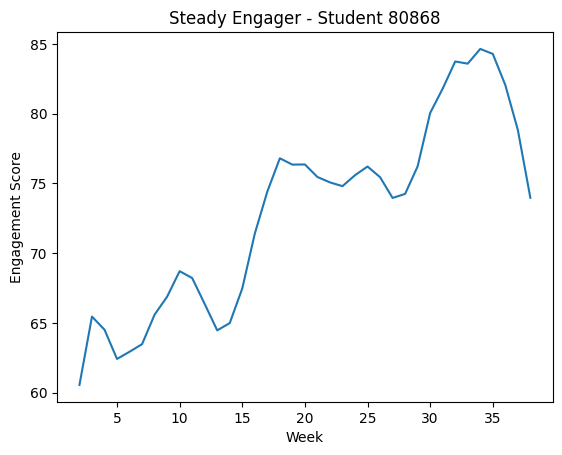

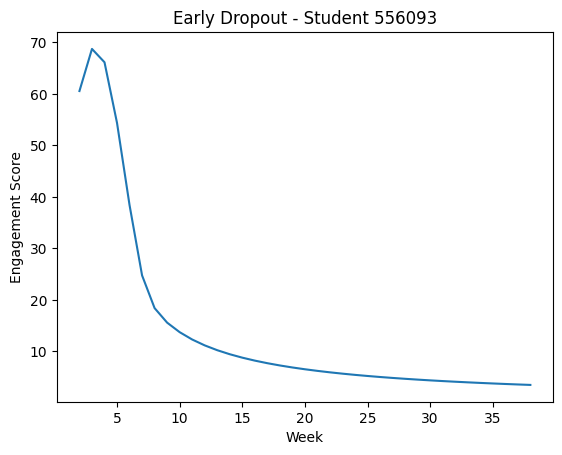

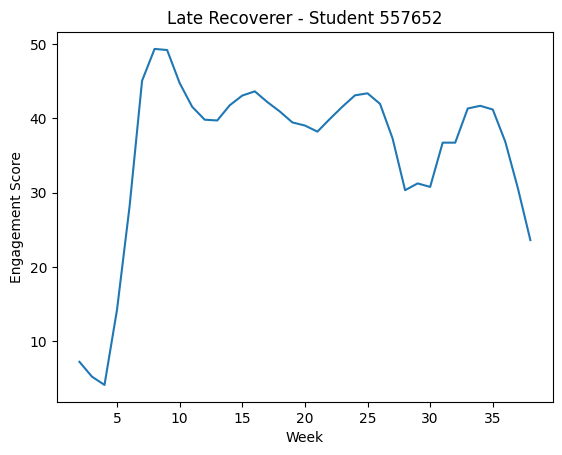

In [ ]:
plot_student(steady, "Steady Engager")
plot_student(early, "Early Dropout")
plot_student(late, "Late Recoverer")

In [ ]:
weekly_clicks.to_csv("engagement_features.csv", index=False)

1. Behavioral features engineered (≥ 5) + justification

Recency (time since last activity)
Captures inactivity. Students with increasing gaps between interactions show higher disengagement risk.

Frequency / Consistency (active weeks ratio)
Measures how regularly a student engages. Consistent weekly activity correlates with persistence.

Cumulative Clicks (total activity)
Reflects overall effort. Higher total engagement generally aligns with better outcomes.

Activity Diversity (number of distinct content types accessed)
Indicates breadth of learning behavior. Students accessing varied resources tend to be more engaged.

Trend (slope of weekly activity)
Captures direction of engagement. A negative trend signals declining interest, while positive trend indicates improvement.

Scaled Clicks (normalized activity level)
Ensures comparability across students with different activity ranges.

2. Dynamic scoring (week-by-week)

The engagement score is computed for each week using cumulative and recent behavioral features up to that week.
This makes the score dynamic, allowing it to evolve over time rather than being a static end-of-course measure.

3. Engagement trajectories (archetypes)

Steady Engager:
Consistent activity across weeks → stable high engagement score

Early Dropout:
High initial activity followed by sharp decline → rapidly decreasing score

Late Recoverer:
Low early activity followed by gradual increase → improving score over time

These trajectories demonstrate that the score captures behavioral patterns over time, not just final outcomes.

4. Overall justification

Each feature was selected because it captures a distinct dimension of engagement:

Recency → inactivity

Consistency → habit

Diversity → learning breadth

Trend → behavioral change

Activity volume → effort

Together, they provide a holistic and time-sensitive representation of engagement, enabling the score to reflect a student’s current trajectory rather than static performance.